# 04 — Modelo B: RGB + NIR (4 canais)

Adicionamos a banda **infravermelho próximo (B8)** ao RGB. O NIR é a base do NDVI e tende a ajudar muito na distinção de vegetação.

**Tudo o mais é idêntico ao Modelo A** (mesma seed, arquitetura, normalização, callbacks). A única mudança: 4 canais de entrada em vez de 3.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

from src import config, data_loader as dl, models, training, evaluation
from src import visualization as viz

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
mixed_precision.set_global_policy('mixed_float16')
tf.random.set_seed(config.SEED); np.random.seed(config.SEED)
config.ensure_dirs()

MODEL_NAME = 'model_b_rgb_nir'
CHANNELS = config.RGB_NIR_INDICES
print('Canais:', [config.BAND_NAMES[i] for i in CHANNELS])

I0000 00:00:1780159722.632185   14023 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Canais: ['B4', 'B3', 'B2', 'B8']


In [2]:
train_ds, val_ds, test_ds = dl.make_splits()
mean, std = dl.load_norm_stats()

train_pipe = dl.build_pipeline(train_ds, CHANNELS, mean, std, augment=True, shuffle=True)
val_pipe = dl.build_pipeline(val_ds, CHANNELS, mean, std, augment=False, shuffle=False)
test_pipe = dl.build_pipeline(test_ds, CHANNELS, mean, std, augment=False, shuffle=False)

I0000 00:00:1780159728.420457   14023 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6


In [3]:
model = models.build_cnn(input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, len(CHANNELS)))
training.compile_model(model)
model.summary()

Model: "eurosat_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             

 Total params: 289,930 (1.11 MB)

 Trainable params: 289,034 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [4]:
history, train_time = training.train_model(model, train_pipe, val_pipe, MODEL_NAME)
print(f'\nTempo de treino: {train_time:.0f}s')

Epoch 1/50


I0000 00:00:1780159732.552468   14195 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
I0000 00:00:1780159736.510001   14112 service.cc:153] XLA service 0x7bf41403d4f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780159736.510048   14112 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780159736.715799   14112 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780159737.446122   14112 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780159737.532279   14112 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5583__.99
I0000 00:00:1780159757.807100   14112 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at mos

293/296 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6903 - loss: 0.9062

I0000 00:00:1780159767.381709   14111 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5583__.99


296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6912 - loss: 0.9035
Epoch 1: val_accuracy improved from None to 0.78000, saving model to results/models/model_b_rgb_nir.keras

Epoch 1: finished saving model to results/models/model_b_rgb_nir.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - accuracy: 0.7832 - loss: 0.6355 - val_accuracy: 0.7800 - val_loss: 0.6152 - learning_rate: 0.0010
Epoch 2/50
294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8729 - loss: 0.3933
Epoch 2: val_accuracy improved from 0.78000 to 0.87704, saving model to results/models/model_b_rgb_nir.keras

Epoch 2: finished saving model to results/models/model_b_rgb_nir.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8850 - loss: 0.3540 - val_accuracy: 0.8770 - val_loss: 0.3651 - learning_rate: 0.0010
Epoch 3/50
291/296 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8982 - loss: 0.3023
Epoch 3: val_accuracy improved from 0.87704 to 0.90815, saving model to results/models/model_b_rgb_nir.ke

## Avaliação no teste

In [5]:
metrics = evaluation.evaluate_on_test(model, test_pipe)
print(f"Acurácia (teste): {metrics['accuracy']:.4f}")
print(f"F1 macro (teste): {metrics['f1_macro']:.4f}")
print()
print(evaluation.get_classification_report(metrics['y_true'], metrics['y_pred']))

Acurácia (teste): 0.9805
F1 macro (teste): 0.9795

                      precision    recall  f1-score   support

          AnnualCrop     0.9765    0.9719    0.9742       427
              Forest     0.9828    0.9956    0.9892       458
HerbaceousVegetation     0.9768    0.9525    0.9645       442
             Highway     0.9871    0.9745    0.9807       392
          Industrial     0.9925    0.9876    0.9900       402
             Pasture     0.9530    0.9827    0.9676       289
       PermanentCrop     0.9552    0.9552    0.9552       357
         Residential     0.9890    0.9956    0.9923       452
               River     0.9834    0.9834    0.9834       362
             SeaLake     0.9958    1.0000    0.9979       469

            accuracy                         0.9805      4050
           macro avg     0.9792    0.9799    0.9795      4050
        weighted avg     0.9805    0.9805    0.9805      4050



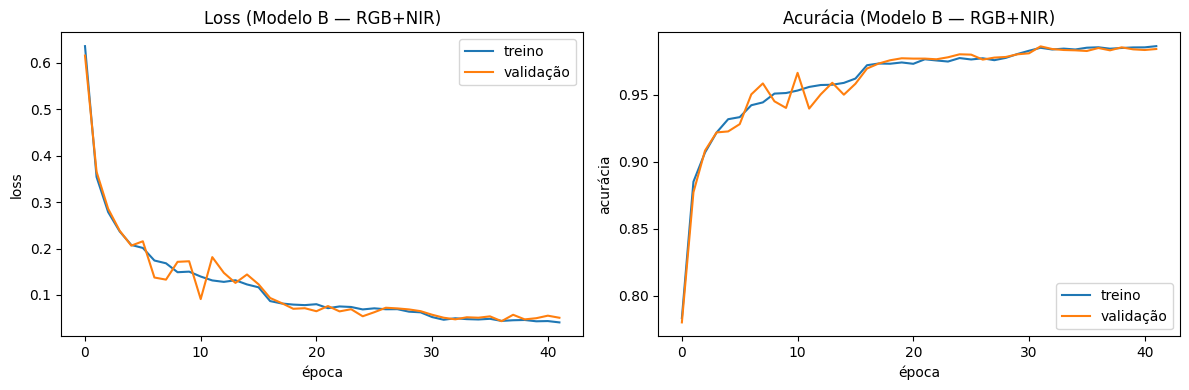

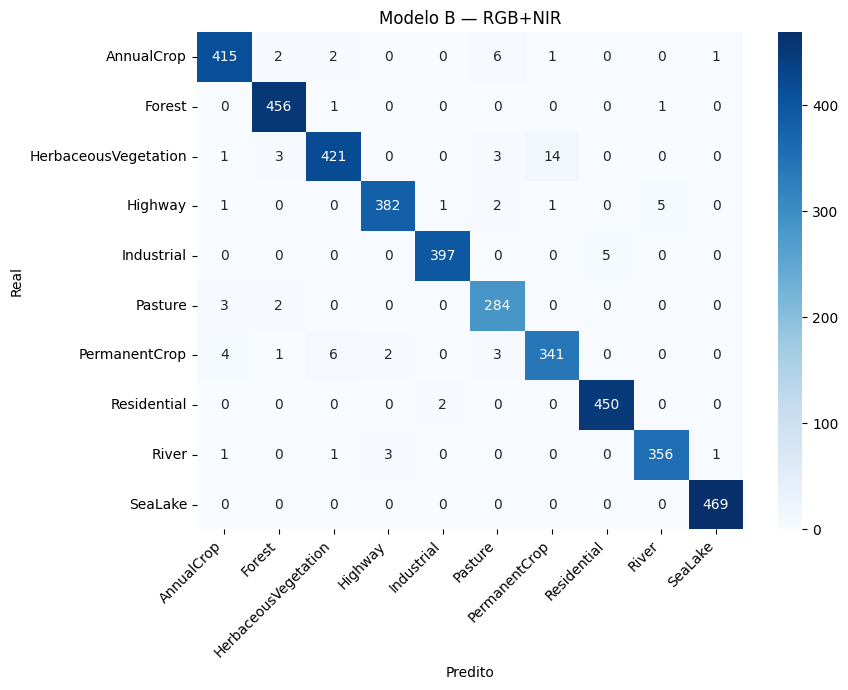

In [6]:
viz.plot_learning_curves(history, save_path=config.FIGURES_DIR / f'{MODEL_NAME}_curves.png', title_suffix='(Modelo B — RGB+NIR)')
plt.show()

cm, _ = evaluation.compute_confusion_matrix(metrics['y_true'], metrics['y_pred'])
viz.plot_confusion_matrix(cm, save_path=config.FIGURES_DIR / f'{MODEL_NAME}_confusion.png', title='Modelo B — RGB+NIR')
plt.show()

In [7]:
metrics['train_time_s'] = float(train_time)
metrics['num_params'] = int(model.count_params())
metrics['channels'] = [config.BAND_NAMES[i] for i in CHANNELS]
evaluation.save_metrics(metrics, config.METRICS_DIR / f'{MODEL_NAME}.json')

with open(config.HISTORIES_DIR / f'{MODEL_NAME}.json', 'w') as f:
    json.dump(history.history, f, indent=2)
print('Resultados salvos para', MODEL_NAME)

Resultados salvos para model_b_rgb_nir


**Próximo passo:** `05_train_model_c_multispectral.ipynb` — todas as 13 bandas.